# Explore here

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from typing import Dict, List, Tuple
import joblib
import matplotlib as mpl
import warnings
# modelado
from sklearn.model_selection import train_test_split, GridSearchCV

# escalado y encoding
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:


archivo = '/workspaces/antonio.romero.machine-learning-python-template/data/raw/internal-link.csv'
df = pd.read_csv(archivo)

In [3]:
df['name'] = df['name'].str.replace(r'\$', '', regex=True)

In [4]:
df.head(10)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0
5,5099,Large Cozy 1 BR Apartment In Midtown East,7322,Chris,Manhattan,Murray Hill,40.74767,-73.97500,Entire home/apt,200,3,74,2019-06-22,0.59,1,129
6,5121,BlissArtsSpace!,7356,Garon,Brooklyn,Bedford-Stuyvesant,40.68688,-73.95596,Private room,60,45,49,2017-10-05,0.40,1,0
7,5178,Large Furnished Room Near B'way,8967,Shunichi,Manhattan,Hell's Kitchen,40.76489,-73.98493,Private room,79,2,430,2019-06-24,3.47,1,220
8,5203,Cozy Clean Guest Room - Family Apt,7490,MaryEllen,Manhattan,Upper West Side,40.80178,-73.96723,Private room,79,2,118,2017-07-21,0.99,1,0
9,5238,Cute & Cozy Lower East Side 1 bdrm,7549,Ben,Manhattan,Chinatown,40.71344,-73.99037,Entire home/apt,150,1,160,2019-06-09,1.33,4,188


In [5]:
df.shape

(48895, 16)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [7]:
# porcentage de nulos
top_missing = (
    df.isna().mean().sort_values(ascending=False) * 100
).round(2).reset_index()
top_missing.columns = ["column", "missing_%"]
display(top_missing.head(20))

,column,missing_%
0,last_review,20.56
1,reviews_per_month,20.56
2,host_name,0.04
3,name,0.03
4,neighbourhood_group,0.00
5,neighbourhood,0.00
6,id,0.00
7,host_id,0.00
8,longitude,0.00
9,latitude,0.00


In [8]:
duplicados = df.duplicated()
num_duplicados = duplicados.sum()
df_duplicados = df[duplicados]
print(num_duplicados)
print(duplicados)

0
0        False
1        False
2        False
3        False
4        False
         ...  
48890    False
48891    False
48892    False
48893    False
48894    False
Length: 48895, dtype: bool


In [9]:
df.drop(["id", "host_id", "host_name"], axis = 1, inplace = True)


In [10]:
df.head()

,name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,Clean & quiet apt home by the park,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,Skylit Midtown Castle,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,THE VILLAGE OF HARLEM....NEW YORK !,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,Cozy Entire Floor of Brownstone,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,Entire Apt: Spacious Studio/Loft by central park,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 13 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   name                            48879 non-null  object 
 1   neighbourhood_group             48895 non-null  object 
 2   neighbourhood                   48895 non-null  object 
 3   latitude                        48895 non-null  float64
 4   longitude                       48895 non-null  float64
 5   room_type                       48895 non-null  object 
 6   price                           48895 non-null  int64  
 7   minimum_nights                  48895 non-null  int64  
 8   number_of_reviews               48895 non-null  int64  
 9   last_review                     38843 non-null  object 
 10  reviews_per_month               38843 non-null  float64
 11  calculated_host_listings_count  48895 non-null  int64  
 12  availability_365                

## Variables categóricas

In [12]:
df.name.value_counts()

name
Hillside Hotel                                        18
Home away from home                                   17
New york Multi-unit building                          16
Brooklyn Apartment                                    12
Private Room                                          11
                                                      ..
Spacious Modern Alcove Studio in a Luxury Building     1
Artist's Room in Large Apartment                       1
Modern Oasis in Central Park Slope                     1
One BR upper east, walk out to garden                  1
ASTORIA APARTMENT OUTDOOR SPACE                        1
Name: count, Length: 47905, dtype: int64

In [13]:
df.neighbourhood_group.value_counts()

neighbourhood_group
Manhattan        21661
Brooklyn         20104
Queens            5666
Bronx             1091
Staten Island      373
Name: count, dtype: int64

In [14]:
df.neighbourhood.value_counts()

neighbourhood
Williamsburg          3920
Bedford-Stuyvesant    3714
Harlem                2658
Bushwick              2465
Upper West Side       1971
                      ... 
Richmondtown             1
Fort Wadsworth           1
New Dorp                 1
Rossville                1
Willowbrook              1
Name: count, Length: 221, dtype: int64

In [15]:
df.room_type.value_counts()

room_type
Entire home/apt    25409
Private room       22326
Shared room         1160
Name: count, dtype: int64

In [16]:
df.last_review.value_counts()

last_review
2019-06-23    1413
2019-07-01    1359
2019-06-30    1341
2019-06-24     875
2019-07-07     718
              ... 
2017-01-12       1
2011-12-28       1
2017-10-05       1
2018-01-29       1
2018-03-29       1
Name: count, Length: 1764, dtype: int64

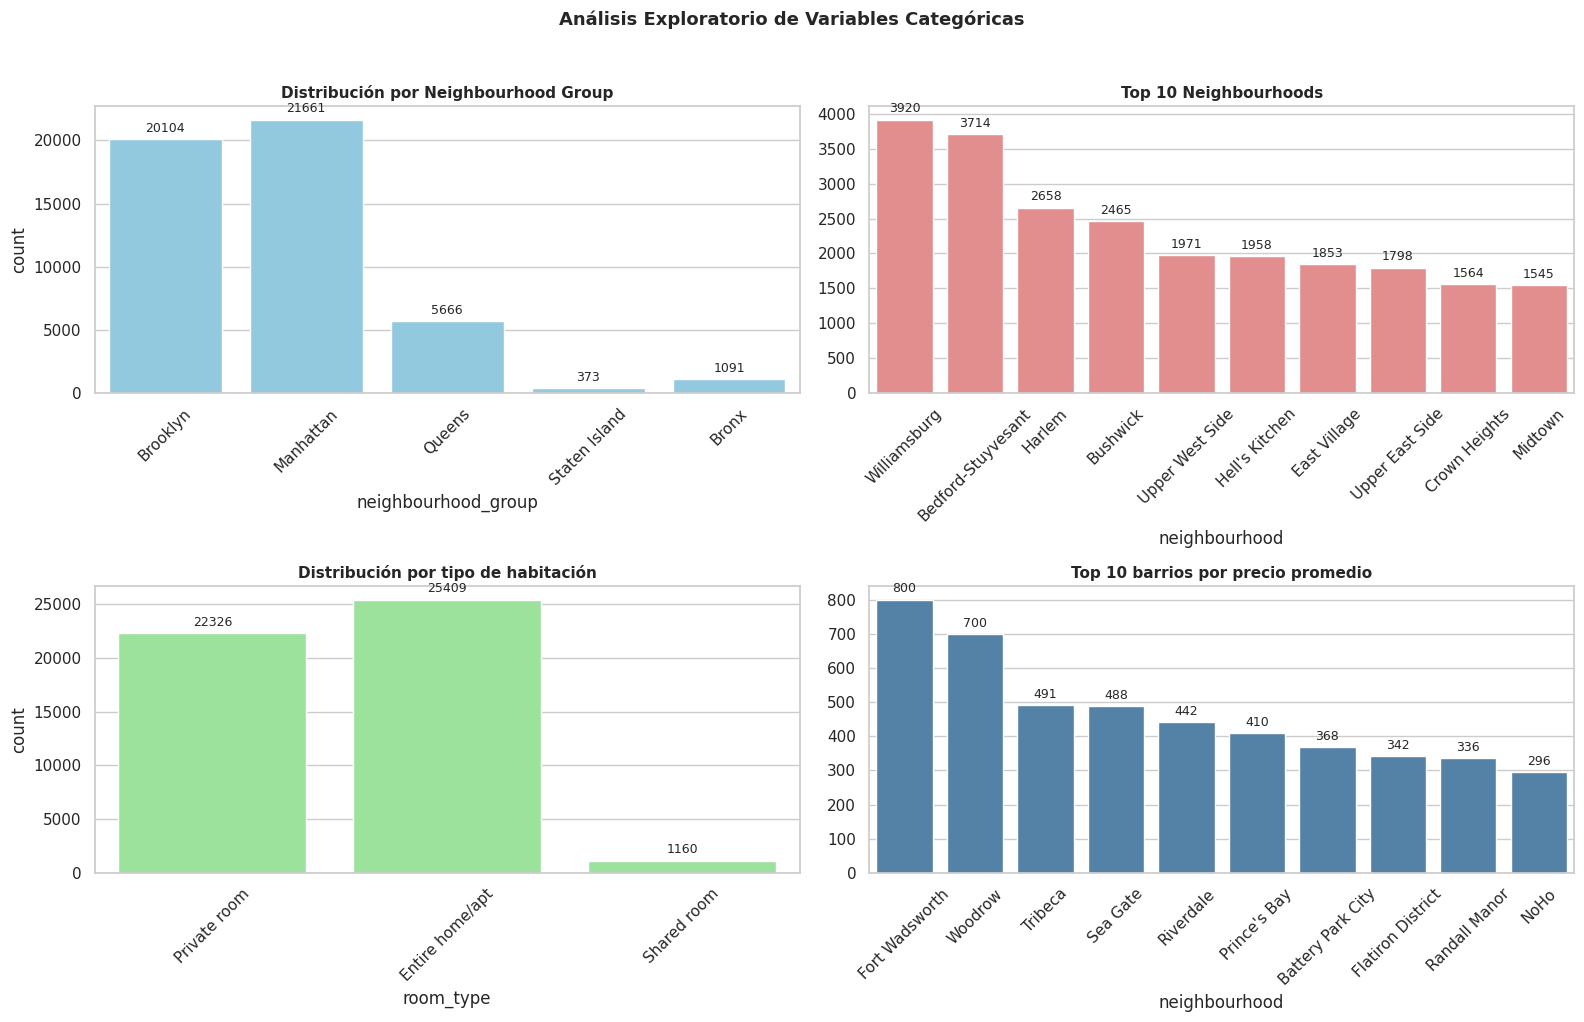

In [17]:
sns.set_theme(style="whitegrid")
mpl.rcParams['text.usetex'] = False
warnings.filterwarnings("ignore", message="Glyph .* missing from font")

fig, axis = plt.subplots(2, 2, figsize=(16, 10))

# Distribución por Neighbourhood Group
ax = sns.countplot(ax=axis[0, 0], data=df, x="neighbourhood_group", color="skyblue")
axis[0, 0].set_title("Distribución por Neighbourhood Group", fontsize=11, fontweight="bold")
axis[0, 0].tick_params(axis='x', rotation=45)

for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontsize=9, padding=3)

# Top 10 Neighbourhood
top_neigh = df['neighbourhood'].value_counts().head(10)
ax = sns.barplot(ax=axis[0, 1], x=top_neigh.index, y=top_neigh.values, color="lightcoral")
axis[0, 1].set_title("Top 10 Neighbourhoods", fontsize=11, fontweight="bold")
axis[0, 1].tick_params(axis='x', rotation=45)
for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontsize=9, padding=3)

# Distribución por tipo de habitación
ax = sns.countplot(ax=axis[1, 0], data=df, x="room_type", color="lightgreen")
axis[1, 0].set_title("Distribución por tipo de habitación", fontsize=11, fontweight="bold")
axis[1, 0].tick_params(axis='x', rotation=45)
for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontsize=9, padding=3)

# Top 10 barrios por precio promedio
top_price = (
    df.groupby("neighbourhood")["price"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)
ax = sns.barplot(ax=axis[1, 1], x=top_price.index, y=top_price.values, color="steelblue")
axis[1, 1].set_title("Top 10 barrios por precio promedio", fontsize=11, fontweight="bold")
axis[1, 1].tick_params(axis='x', rotation=45)
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', fontsize=9, padding=3)

# Ajustes finales
plt.suptitle("Análisis Exploratorio de Variables Categóricas", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()



### Análisis de las categorías: 
Barrios: La mayor parte de alojamientos se concentran en los grupos de vecindarios de Manhattan y Brooklyn (85% del total aprox.). Los barrios de Williamsburg, Bedford y Harlem concentran el mayor número de alojamientos

Tipos de habitación: el mercado parece orientado a viviendas completas, seguido por alquiler de habitaciones privadas. Las habitaciones compartidas no sobrepasan el 3%

Precios: el precio medio más elevado se encuentra principalmente en Manhattan. hay una dispersión de precios notable, multiplicando exponencialmente el valor medio general



## Variables numéricas

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 13 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   name                            48879 non-null  object 
 1   neighbourhood_group             48895 non-null  object 
 2   neighbourhood                   48895 non-null  object 
 3   latitude                        48895 non-null  float64
 4   longitude                       48895 non-null  float64
 5   room_type                       48895 non-null  object 
 6   price                           48895 non-null  int64  
 7   minimum_nights                  48895 non-null  int64  
 8   number_of_reviews               48895 non-null  int64  
 9   last_review                     38843 non-null  object 
 10  reviews_per_month               38843 non-null  float64
 11  calculated_host_listings_count  48895 non-null  int64  
 12  availability_365                

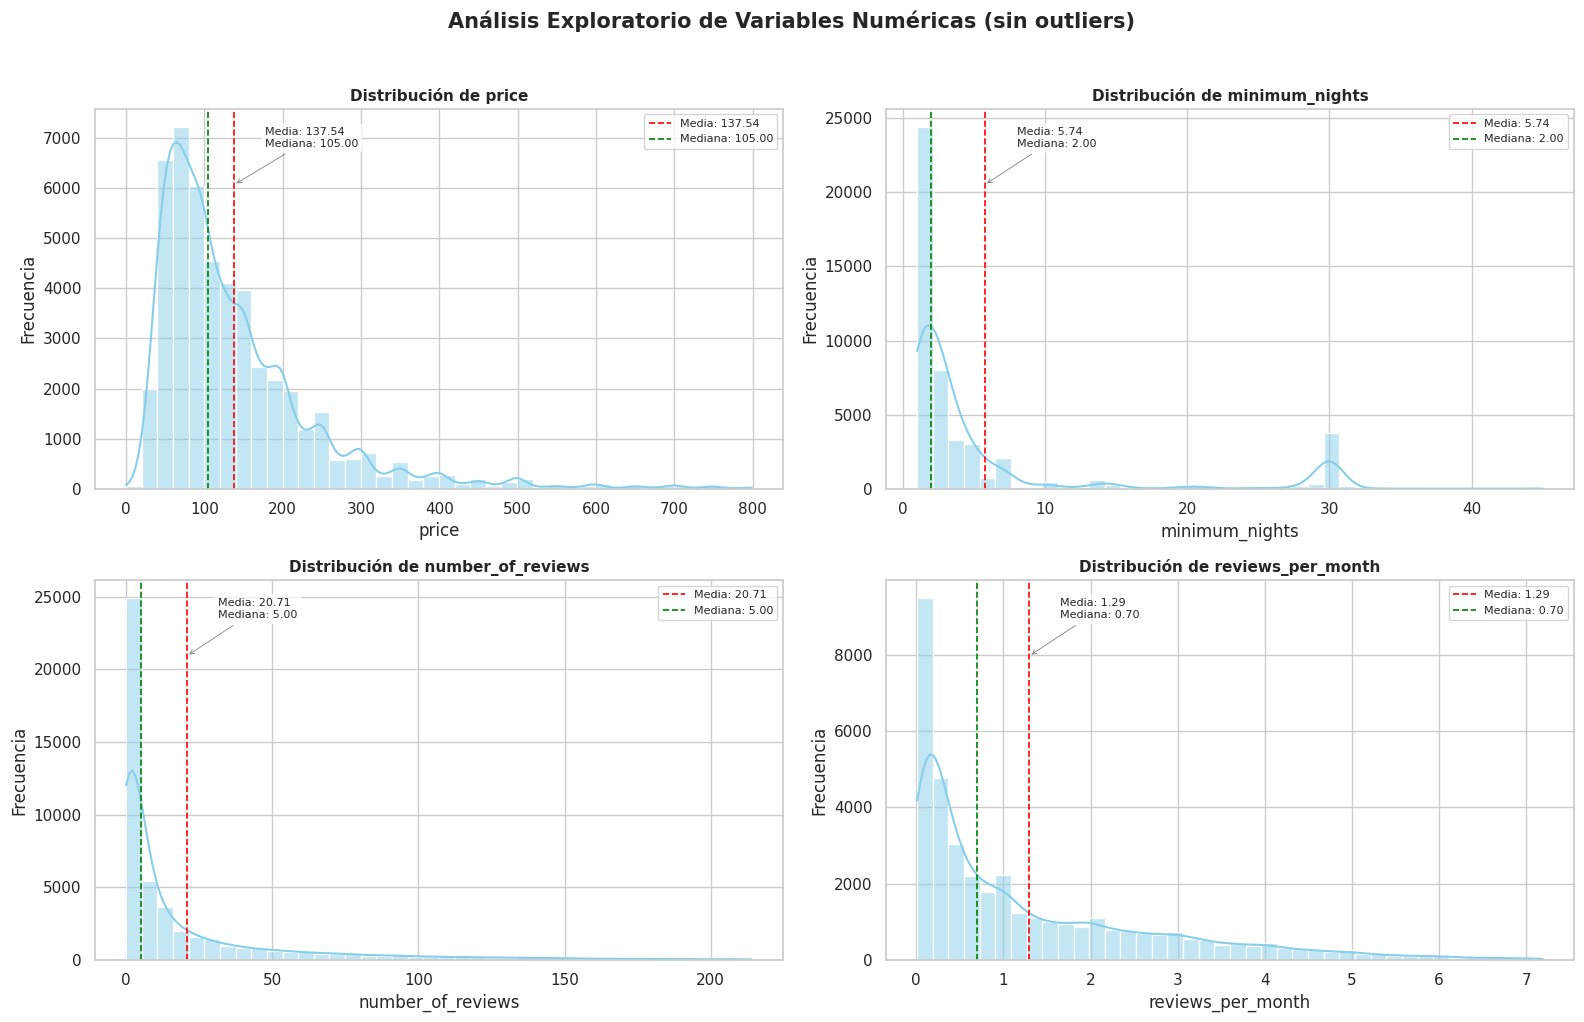

In [19]:
sns.set_theme(style="whitegrid")
warnings.filterwarnings("ignore", message="Glyph .* missing from font")

fig, axis = plt.subplots(2, 2, figsize=(16, 10))
axis = axis.flatten()

plots = {
    0: "price",
    1: "minimum_nights",
    2: "number_of_reviews",
    3: "reviews_per_month"
}

for i, col in plots.items():
    ax = axis[i]

    # Limitar el rango al percentil 99 para representar mejor las colas
    upper_limit = df[col].quantile(0.99)

    sns.histplot(data=df[df[col] <= upper_limit], x=col, bins=40, kde=True, color="skyblue", ax=ax)
    ax.set_title(f"Distribución de {col}", fontsize=11, fontweight="bold")
    ax.set_xlabel(col)
    ax.set_ylabel("Frecuencia")

    # Estadísticos sobre el subconjunto limitado
    mean_val = df[df[col] <= upper_limit][col].mean()
    median_val = df[df[col] <= upper_limit][col].median()

    # Líneas de referencia
    ax.axvline(mean_val, color="red", linestyle="--", linewidth=1.2, label=f"Media: {mean_val:,.2f}")
    ax.axvline(median_val, color="green", linestyle="--", linewidth=1.2, label=f"Mediana: {median_val:,.2f}")

    # Anotaciones
    ax.annotate(f"Media: {mean_val:,.2f}\nMediana: {median_val:,.2f}",
                xy=(mean_val, ax.get_ylim()[1]*0.8),
                xytext=(mean_val + (upper_limit*0.05), ax.get_ylim()[1]*0.9),
                fontsize=8,
                bbox=dict(facecolor='white', alpha=0.7, boxstyle='round,pad=0.3'),
                arrowprops=dict(arrowstyle="->", lw=0.6, color="gray"))

    ax.legend(fontsize=8)

plt.suptitle("Análisis Exploratorio de Variables Numéricas (sin outliers)", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### Variables numéricas:

Price: la distribución se encuentra en la parte izquierda de la tabla. La mayor parte de precios se encuentran por debajo de 250€, aunque algunos apartamentos superan los 1000€.

Minimum nights: la mayor parte exigen estancias mínimas cortas de entre 2 y 5 noches. Los outliers con más de 100 noches pueden considerarse alquileres de largo plazo, pero son marginales a la tendencia general.

Reviews: pese a que existen propiedades con más de 3 reseñas al mes, la muestra refleja por debajo de una reseña al mes. La mayor parte de reseñas se concentran en valores bajos, es decir unas cuantas propiedades son populares, pero la mayor parte mantiene valores bajos.

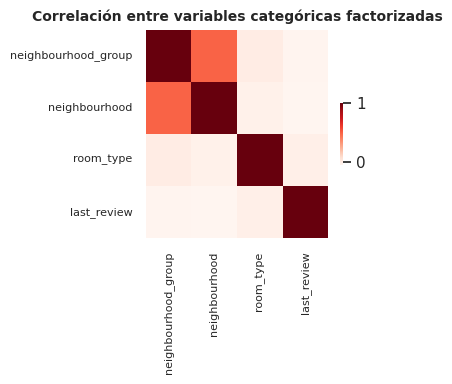

In [20]:
# Factorizamos para ver la relación entre variables
df["neighbourhood_group"] = pd.factorize(df["neighbourhood_group"])[0]
df["neighbourhood"] = pd.factorize(df["neighbourhood"])[0]
df["room_type"] = pd.factorize(df["room_type"])[0]
df["last_review"] = pd.factorize(df["last_review"])[0]

fig, axis = plt.subplots(figsize = (4, 4))

sns.heatmap(df[["neighbourhood_group", "neighbourhood", "room_type", "last_review"]].corr(),
fmt=".2f",
cmap="Reds",
annot_kws={"size": 4},       # tamaño de los números dentro de las celdas
cbar_kws={"shrink": 0.3}     # tamaño de la barra de color
)

axis.set_title("Correlación entre variables categóricas factorizadas", fontsize=10, fontweight="bold")
axis.tick_params(labelsize=8)    # tamaño de etiquetas del eje

plt.tight_layout()
plt.show()



### Correlación entre variables categóricas.
No parece existir una correlación excepto entre grupo de barrios y barrios

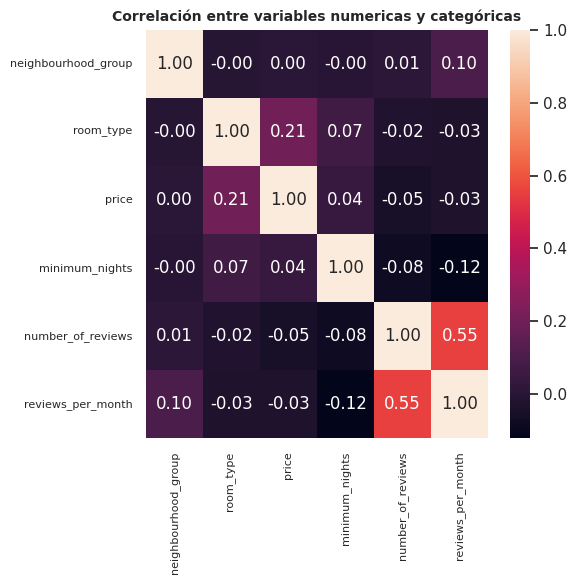

In [21]:
fig, axis = plt.subplots(figsize = (6, 6))

sns.heatmap(df[["neighbourhood_group", "room_type", "price", "minimum_nights", "number_of_reviews", "reviews_per_month"]].corr(), 
annot = True, 
fmt = ".2f"),
annot_kws={"size": 4},       # tamaño de los números dentro de las celdas
cbar_kws={"shrink": 0.3} 

axis.set_title("Correlación entre variables numericas y categóricas", fontsize=10, fontweight="bold")
axis.tick_params(labelsize=8)    # tamaño de etiquetas del eje
plt.tight_layout()

plt.show()

### Análisis de variables numéricas y categóricas.

No parece haber una correlación fuerte entre las categorías excepto en las lógicas esperadas. 

Por ejemplo cuanto más reviews totales, mayor frecuencia de reviews mensuales, lo que indica mayor rotación de clientes. Los alojamientos completos suelen presentar precios más altos que las habitaciones compartidas o privadas.

### Preproceso train y test

In [22]:
# Dividimos el conjunto de datos en muestras de train y test
y = df["price"]                      # objetivo
X = df.drop(columns=["price", "name"])  # excluimos name

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train.head()

,neighbourhood_group,neighbourhood,latitude,longitude,room_type,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
32645,0,12,40.71577,-73.95530,1,3,11,43,0.87,1,1
23615,1,30,40.84917,-73.94048,0,2,2,548,0.16,1,0
31183,0,6,40.68993,-73.95947,0,2,0,-1,NaN,2,0
29260,0,6,40.68427,-73.93118,1,3,87,2,4.91,1,267
7275,2,31,40.74705,-73.89564,0,5,13,1379,0.25,1,0


In [23]:
X_train.shape

(39116, 11)

In [24]:
X_test.shape

(9779, 11)

In [25]:
X_test

,neighbourhood_group,neighbourhood,latitude,longitude,room_type,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
879,0,0,40.64354,-73.97777,1,3,62,48,0.71,1,189
44383,2,44,40.70666,-73.90779,0,21,0,-1,NaN,1,73
15394,1,7,40.76116,-73.99016,0,2,17,1045,0.43,1,0
43230,1,43,40.70763,-74.01050,1,2,5,70,1.88,327,272
16332,1,4,40.79658,-73.93287,1,2,30,116,0.80,1,30
...,...,...,...,...,...,...,...,...,...,...,...
20477,1,19,40.72543,-73.99129,1,2,18,116,0.70,1,68
44969,1,1,40.76352,-73.98280,0,1,0,-1,NaN,6,294
36577,2,37,40.75914,-73.83352,0,1,5,37,0.82,4,5
11477,1,19,40.72179,-73.97951,1,2,0,-1,NaN,1,0


In [26]:
y_test

879       89
44383     30
15394    120
43230    470
16332    199
        ... 
20477    215
44969    100
36577     70
11477    500
1023     125
Name: price, Length: 9779, dtype: int64

In [27]:
### Escalado (variables categóricas)

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 13 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   name                            48879 non-null  object 
 1   neighbourhood_group             48895 non-null  int64  
 2   neighbourhood                   48895 non-null  int64  
 3   latitude                        48895 non-null  float64
 4   longitude                       48895 non-null  float64
 5   room_type                       48895 non-null  int64  
 6   price                           48895 non-null  int64  
 7   minimum_nights                  48895 non-null  int64  
 8   number_of_reviews               48895 non-null  int64  
 9   last_review                     48895 non-null  int64  
 10  reviews_per_month               38843 non-null  float64
 11  calculated_host_listings_count  48895 non-null  int64  
 12  availability_365                

In [29]:
# listamos las columnas existentes y entrenamos
num_cols = [c for c in [
    "latitude", "longitude", "minimum_nights", "number_of_reviews",
    "reviews_per_month", "calculated_host_listings_count", "availability_365"
] if c in X_train.columns]

cat_cols = [c for c in [
    "neighbourhood_group", "neighbourhood", "room_type", "last_review"
] if c in X_train.columns]